# Cleaning code and EDA.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("D:\MLCOE PROBATION TASKS\TASK 3\Data\globalterrorismdb_reduced_stage1.csv", encoding="latin-1", low_memory=False)
print("Loaded:", df.shape)

Loaded: (181691, 83)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 83 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   eventid             181691 non-null  int64  
 1   iyear               181691 non-null  int64  
 2   imonth              181691 non-null  int64  
 3   iday                181691 non-null  int64  
 4   approxdate          9239 non-null    object 
 5   extended            181691 non-null  int64  
 6   resolution          2220 non-null    object 
 7   country_txt         181691 non-null  object 
 8   region_txt          181691 non-null  object 
 9   provstate           181270 non-null  object 
 10  city                181256 non-null  object 
 11  latitude            177135 non-null  float64
 12  longitude           177134 non-null  float64
 13  specificity         181685 non-null  float64
 14  vicinity            181691 non-null  int64  
 15  location            55495 non-null

In [6]:
print(f"Average(nperps): {df["nperps"].mean():.2f}") 
print(f"Minimum(nperps): {df["nperps"].min()}")

Average(nperps): -65.36
Minimum(nperps): -99.0


In [7]:
print(f"Average(nperpcap): {df["nperpcap"].mean():.2f}") 
print(f"Minimum(nperpcap): {df["nperpcap"].min()}")

Average(nperpcap): -1.52
Minimum(nperpcap): -99.0


**Insights**: These two columns is giving negative values of mean and minimu, hence there are some negative values.

In [8]:
cols_count = {"nperps": -99, "nperpcap": -99}
for col, sentinel in cols_count.items():
    n = (df[col] == sentinel).sum()
    print(f"{col}: {n} rows ({n/len(df)*100:.1f}%) were sentinel {sentinel} -> NaN")
    df[f"{col}_was_unknown"] = (df[col] == sentinel).astype(int)
    df.loc[df[col] == sentinel, col] = np.nan

nperps: 82218 rows (45.3%) were sentinel -99 -> NaN
nperpcap: 1862 rows (1.0%) were sentinel -99 -> NaN


**Insight**: Changed the sentinel value with NAN.

**Insight**: Below columns have specifically the yes, no but written as -- (0, 1, and -9). Now doing the similar thing -9 here. changing -9 with unknown and 0 with no and 1 with yes.

In [9]:
flag_cols = ["property", "ishostkid", "claimed", "ransom", "vicinity",
                  "doubtterr", "INT_LOG", "INT_IDEO", "INT_MISC", "INT_ANY"]
for col in flag_cols:
    n = (df[col] == -9).sum()
    print(f"{col}: {n} rows ({n/len(df)*100:.1f}%) relabelled -9 -> 'Unknown'")
    df[col] = df[col].map({-9: "Unknown", 0: "No", 1: "Yes"}).fillna("Unknown")

property: 21386 rows (11.8%) relabelled -9 -> 'Unknown'
ishostkid: 317 rows (0.2%) relabelled -9 -> 'Unknown'
claimed: 1474 rows (0.8%) relabelled -9 -> 'Unknown'
ransom: 1398 rows (0.8%) relabelled -9 -> 'Unknown'
vicinity: 35 rows (0.0%) relabelled -9 -> 'Unknown'
doubtterr: 13784 rows (7.6%) relabelled -9 -> 'Unknown'
INT_LOG: 92527 rows (50.9%) relabelled -9 -> 'Unknown'
INT_IDEO: 92659 rows (51.0%) relabelled -9 -> 'Unknown'
INT_MISC: 487 rows (0.3%) relabelled -9 -> 'Unknown'
INT_ANY: 83830 rows (46.1%) relabelled -9 -> 'Unknown'


In [10]:
n_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes}")
if n_dupes > 0:
    df = df.drop_duplicates()
    print("Dropped duplicates.")

Fully duplicated rows: 0


In [12]:
print(df.shape)

(181691, 85)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 85 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   eventid               181691 non-null  int64  
 1   iyear                 181691 non-null  int64  
 2   imonth                181691 non-null  int64  
 3   iday                  181691 non-null  int64  
 4   approxdate            9239 non-null    object 
 5   extended              181691 non-null  int64  
 6   resolution            2220 non-null    object 
 7   country_txt           181691 non-null  object 
 8   region_txt            181691 non-null  object 
 9   provstate             181270 non-null  object 
 10  city                  181256 non-null  object 
 11  latitude              177135 non-null  float64
 12  longitude             177134 non-null  float64
 13  specificity           181685 non-null  float64
 14  vicinity              181691 non-null  object 
 15  

In [14]:
df.head(5)

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country_txt,region_txt,provstate,...,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related,nperps_was_unknown,nperpcap_was_unknown
0,197000000001,1970,7,2,NaN,0,NaN,Dominican Republic,Central America & Caribbean,NaN,...,NaN,NaN,PGIS,No,No,No,No,NaN,0,0
1,197000000002,1970,0,0,NaN,0,NaN,Mexico,North America,Federal,...,NaN,NaN,PGIS,No,Yes,Yes,Yes,NaN,0,0
2,197001000001,1970,1,0,NaN,0,NaN,Philippines,Southeast Asia,Tarlac,...,NaN,NaN,PGIS,Unknown,Unknown,Yes,Yes,NaN,0,0
3,197001000002,1970,1,0,NaN,0,NaN,Greece,Western Europe,Attica,...,NaN,NaN,PGIS,Unknown,Unknown,Yes,Yes,NaN,0,0
4,197001000003,1970,1,0,NaN,0,NaN,Japan,East Asia,Fukouka,...,NaN,NaN,PGIS,Unknown,Unknown,Yes,Yes,NaN,0,0


In [15]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
eventid,181691.0,2.002705e+11,1.325957e+09,1.970000e+11,1.991021e+11,2.009022e+11,2.014081e+11,2.017123e+11
iyear,181691.0,2.002639e+03,1.325943e+01,1.970000e+03,1.991000e+03,2.009000e+03,2.014000e+03,2.017000e+03
imonth,181691.0,6.467277e+00,3.388303e+00,0.000000e+00,4.000000e+00,6.000000e+00,9.000000e+00,1.200000e+01
iday,181691.0,1.550564e+01,8.814045e+00,0.000000e+00,8.000000e+00,1.500000e+01,2.300000e+01,3.100000e+01
extended,181691.0,4.534622e-02,2.080629e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
latitude,177135.0,2.349834e+01,1.856924e+01,-5.315461e+01,1.151005e+01,3.146746e+01,3.468509e+01,7.463355e+01
longitude,177134.0,-4.586957e+02,2.047790e+05,-8.618590e+07,4.545640e+00,4.324651e+01,6.871033e+01,1.793667e+02
specificity,181685.0,1.451452e+00,9.954295e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00
crit1,181691.0,9.885300e-01,1.064825e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
crit2,181691.0,9.930927e-01,8.282305e-02,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [16]:
print("iday == 0 (unknown day):", (df["iday"] == 0).sum())
print("imonth == 0 (unknown month):", (df["imonth"] == 0).sum())

iday == 0 (unknown day): 891
imonth == 0 (unknown month): 20


In [17]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(1),
}).sort_values("missing_pct", ascending=False)
missing = missing[missing["missing_count"] > 0]
missing

,missing_count,missing_pct
divert,181367,99.8
ransomamtus,181128,99.7
ransompaidus,181139,99.7
ransomnote,181179,99.7
ransompaid,180917,99.6
ransomamt,180341,99.3
resolution,179471,98.8
kidhijcountry,178386,98.2
nhours,177628,97.8
compclaim,176852,97.3


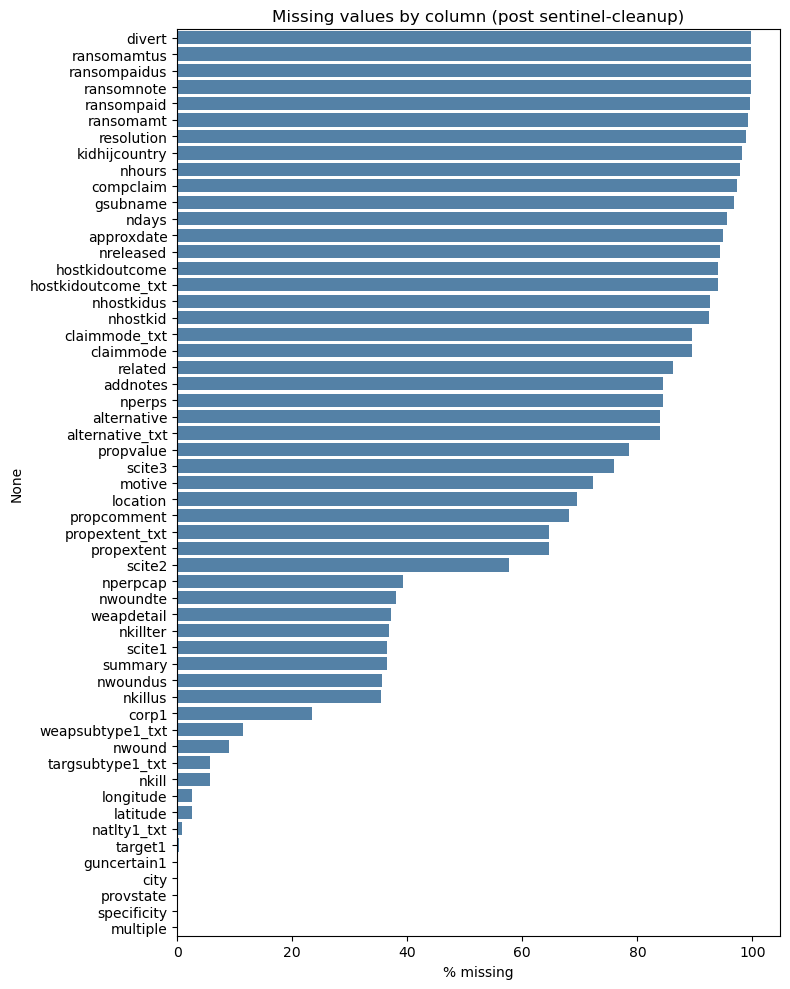

Fully duplicated rows (should be 0, handled in Step 2): 0


In [23]:
plt.figure(figsize=(8, 10))
sns.barplot(x=missing["missing_pct"], y=missing.index, color="steelblue")
plt.xlabel("% missing")
plt.title("Missing values by column (post sentinel-cleanup)")
plt.tight_layout()
plt.show()
 
print("Fully duplicated rows (should be 0, handled in Step 2):", df.duplicated().sum())

In [19]:
numeric_impute_cols = ["nkill", "nwound", "nkillus", "nwoundus",
                        "nkillter", "nwoundte", "nperps", "nperpcap",
                        "latitude", "longitude"]
for col in numeric_impute_cols:
    if df[col].isna().any():
        df[f"{col}_was_missing"] = df[col].isna().astype(int)
        df[col] = df[col].fillna(df[col].median())

In [20]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [21]:
core_cols = numeric_impute_cols + cat_cols
still_missing_in_core = df[core_cols].isna().sum().sum()
print("Nulls remaining in the columns this step actually targeted:", still_missing_in_core)
print("(Total nulls dataset-wide, incl. columns Step 4 will drop:", df.isna().sum().sum(), ")")

Nulls remaining in the columns this step actually targeted: 0
(Total nulls dataset-wide, incl. columns Step 4 will drop: 2505859 )


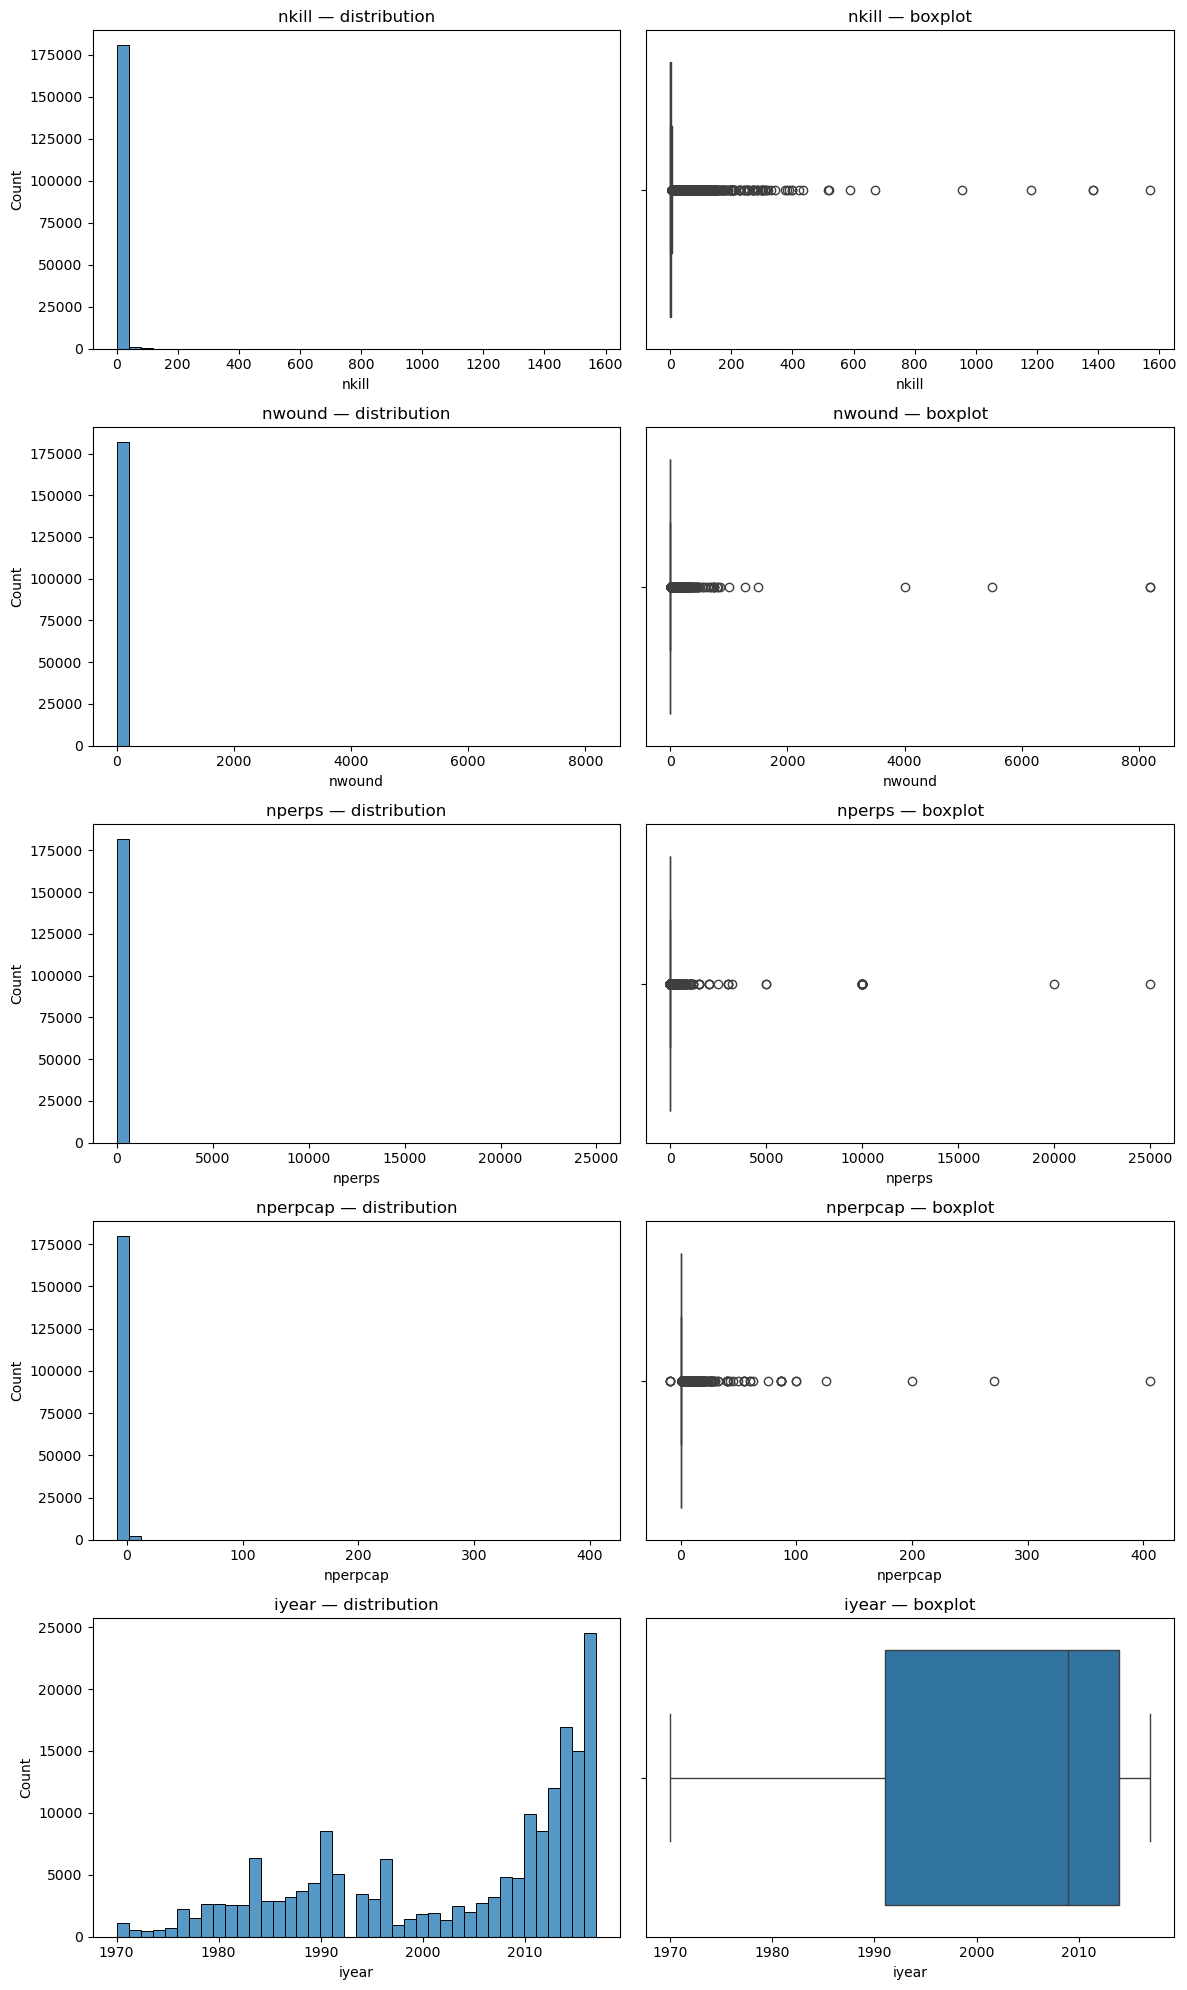

In [24]:
numeric_cols = ["nkill", "nwound", "nperps", "nperpcap", "iyear"]
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4 * len(numeric_cols)))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=40, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} — distribution")
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} — boxplot")
plt.tight_layout()
plt.show()

In [25]:
for col in ["nkill", "nwound"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_outliers = (df[col] > upper).sum()
    print(f"{col}: IQR upper fence = {upper:.1f}, {n_outliers} rows above it "
          f"({n_outliers/len(df)*100:.2f}%)")

nkill: IQR upper fence = 5.0, 16242 rows above it (8.94%)
nwound: IQR upper fence = 5.0, 19850 rows above it (10.93%)


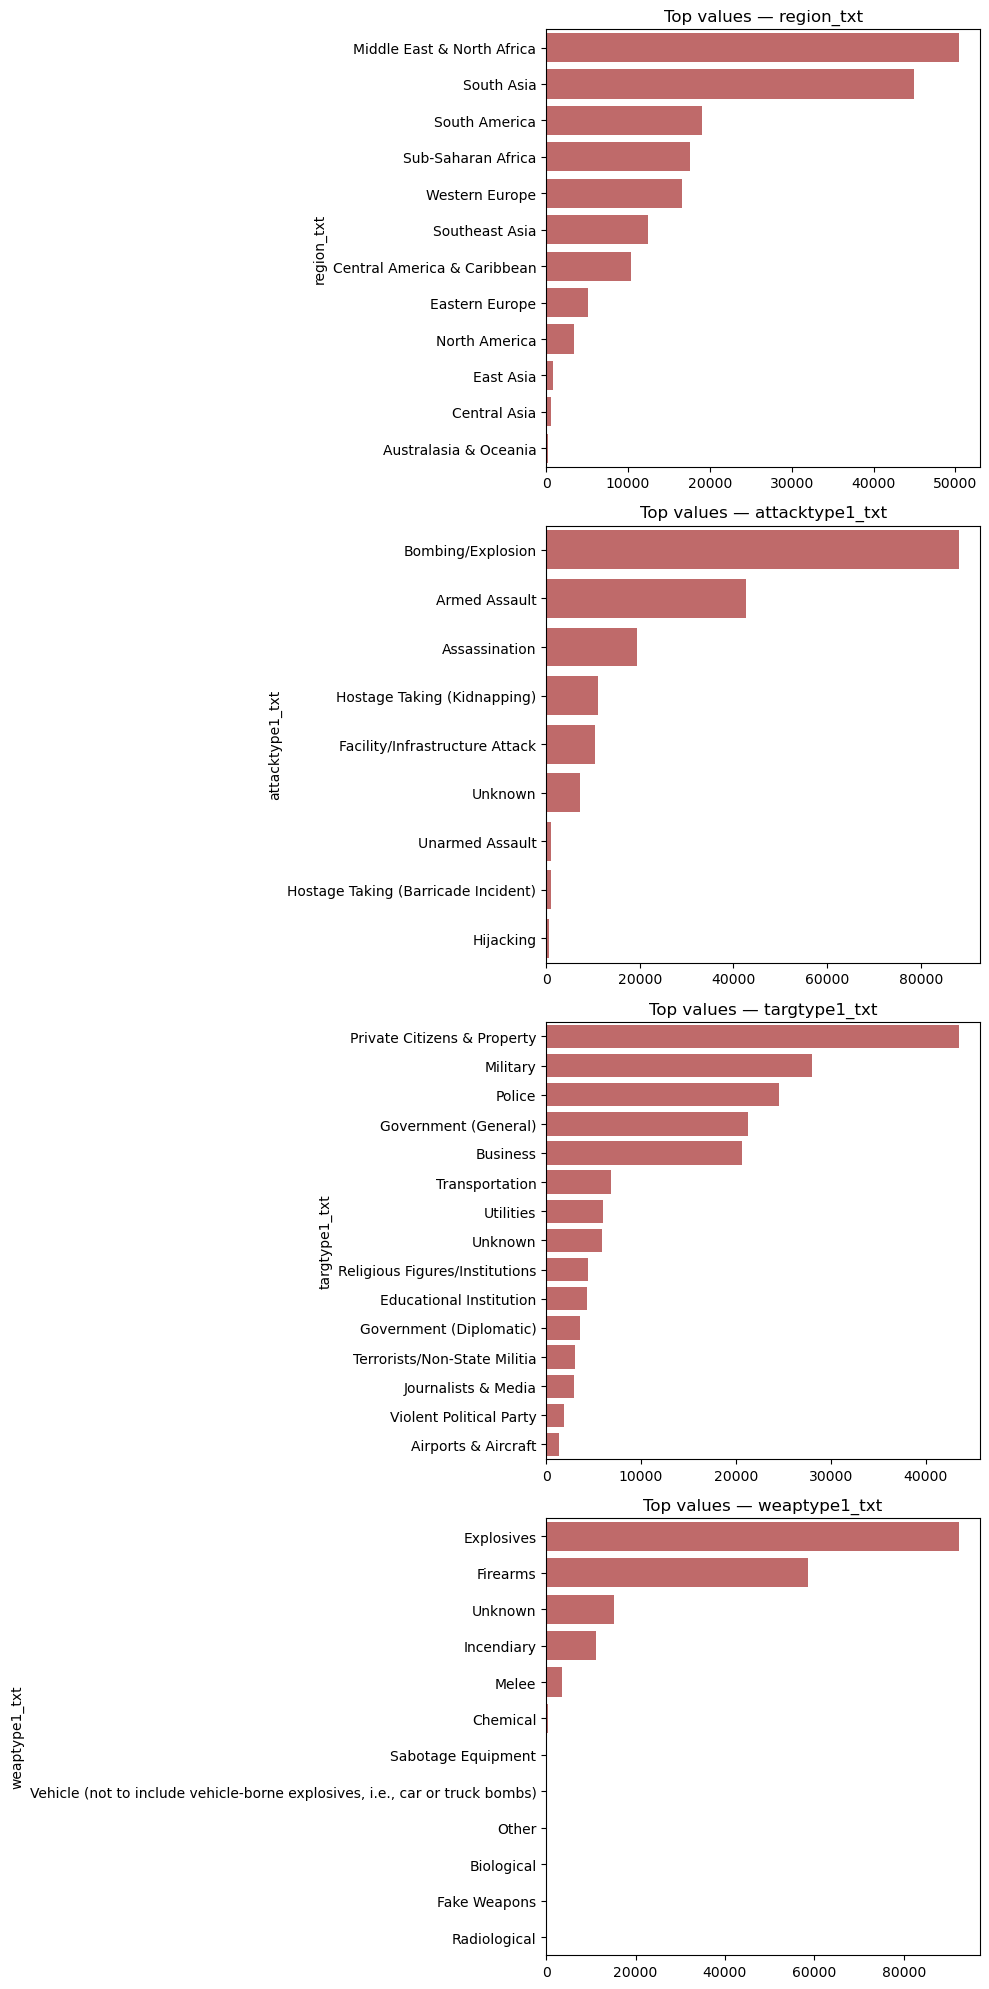

In [ ]:
categorical_cols = ["region_txt", "attacktype1_txt", "targtype1_txt", "weaptype1_txt"]
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(10, 5 * len(categorical_cols)))
for i, col in enumerate(categorical_cols):
    top = df[col].value_counts().head(15)
    sns.barplot(x=top.values, y=top.index, ax=axes[i], color="indianred")
    axes[i].set_title(f"Top values — {col}")
plt.tight_layout()
plt.show()

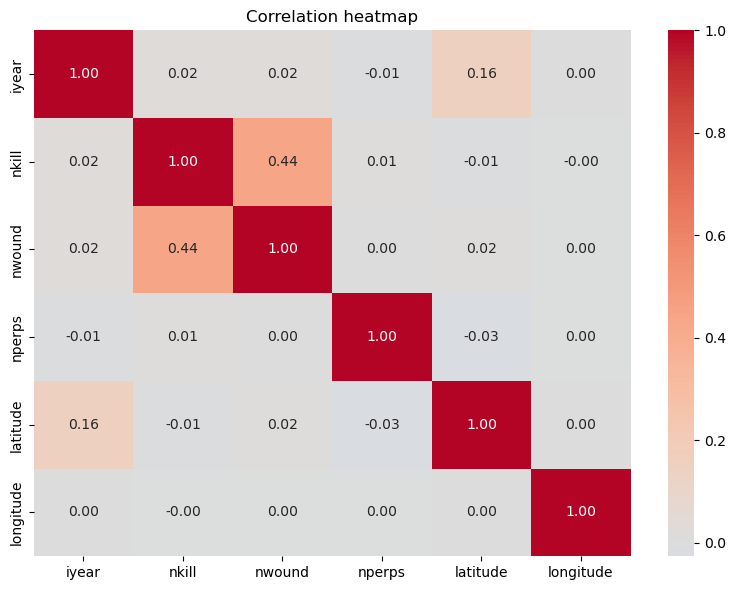

In [27]:
corr_cols = ["iyear", "nkill", "nwound", "nperps", "latitude", "longitude"]
corr = df[corr_cols].corr()
 
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

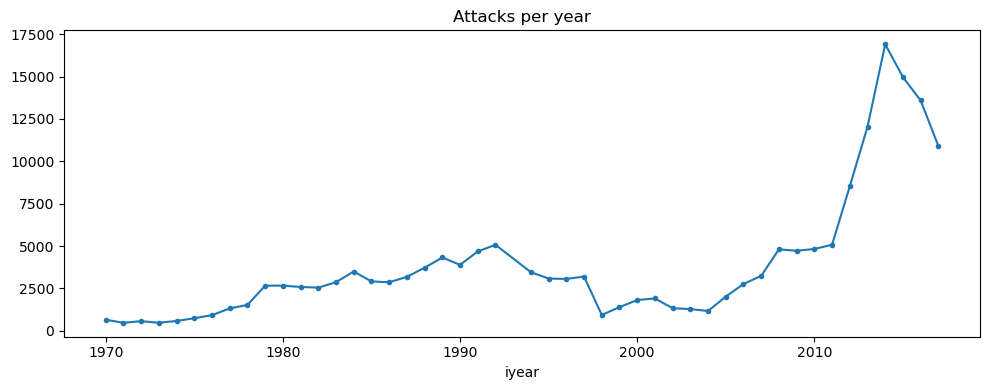

In [28]:
attacks_per_year = df.groupby("iyear").size()
plt.figure(figsize=(10, 4))
attacks_per_year.plot(kind="line", marker="o", markersize=3)
plt.title("Attacks per year")
plt.tight_layout()
plt.show()

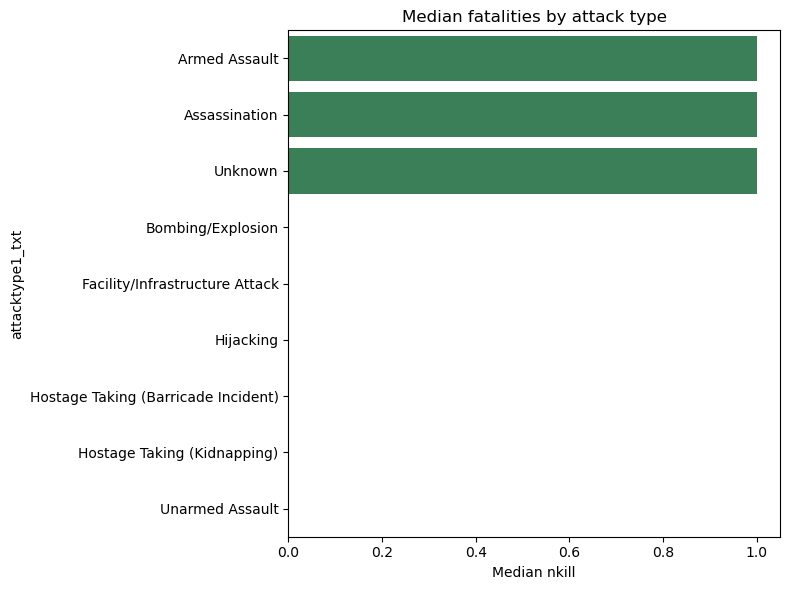

In [29]:
kills_by_attacktype = df.groupby("attacktype1_txt")["nkill"].median().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=kills_by_attacktype.values, y=kills_by_attacktype.index, color="seagreen")
plt.xlabel("Median nkill")
plt.title("Median fatalities by attack type")
plt.tight_layout()
plt.show()

In [30]:
df["decade"] = (df["iyear"] // 10) * 10
df["casualties_total"] = df["nkill"] + df["nwound"]
df["is_multi_faceted"] = (df["multiple"] == 1).astype(int)
df["group_known"] = (df["gname"] != "Unknown").astype(int)
 
print(df[["decade", "casualties_total", "is_multi_faceted", "group_known"]].describe(include="all"))

              decade  casualties_total  is_multi_faceted    group_known
count  181691.000000     181691.000000     181691.000000  181691.000000
mean     1998.128196          5.150156          0.137772       0.544380
std        13.334834         40.555416          0.344662       0.498028
min      1970.000000          0.000000          0.000000       0.000000
25%      1990.000000          0.000000          0.000000       0.000000
50%      2000.000000          1.000000          0.000000       1.000000
75%      2010.000000          4.000000          0.000000       1.000000
max      2010.000000       9574.000000          1.000000       1.000000


In [ ]:
cols = ["eventid", "iyear", "imonth", "country_txt", "region_txt", "provstate",
        "city", "latitude", "longitude", "attacktype1_txt", "targtype1_txt",
        "weaptype1_txt", "gname", "nkill", "nwound", "success", "suicide"]
ind = df[df["country_txt"] == "India"].copy()

In [33]:
print(f"India: {len(ind):,} incidents of {len(df):,} globally "
      f"({len(ind)/len(df)*100:.1f}%), {ind.iyear.min()}-{ind.iyear.max()}")
print("Years with zero India rows:",
      [y for y in range(ind.iyear.min(), ind.iyear.max() + 1) if y not in set(ind.iyear)])

India: 11,960 incidents of 181,691 globally (6.6%), 1972-2017
Years with zero India rows: [1973, 1974, 1978, 1993]


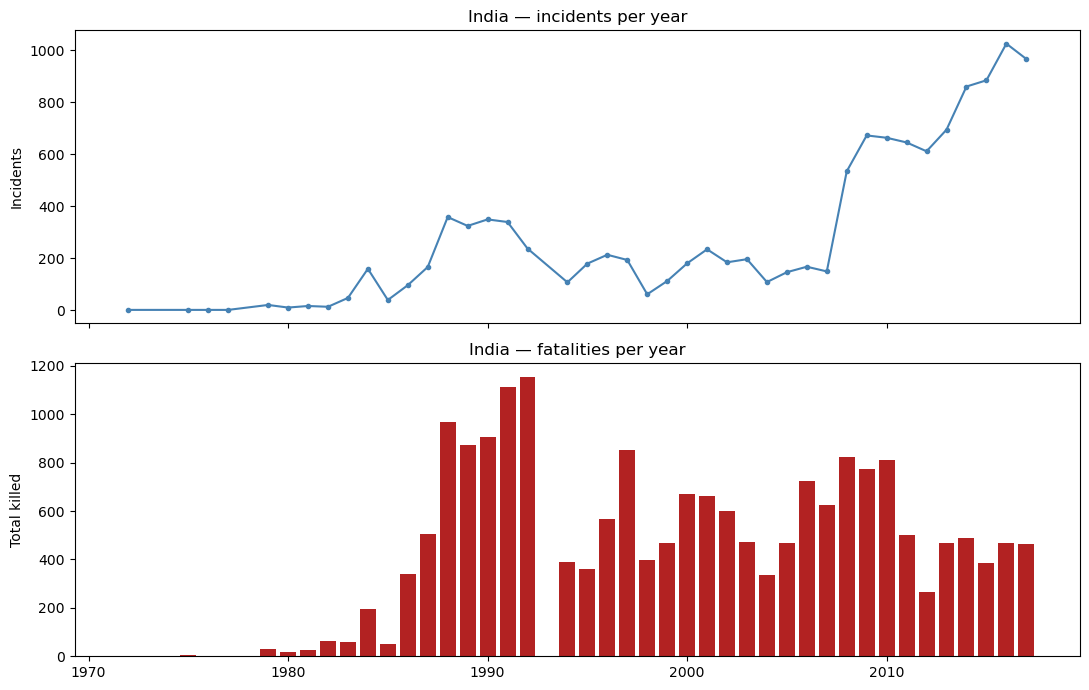

In [34]:
yearly = ind.groupby("iyear").agg(incidents=("eventid", "count"),
                                  killed=("nkill", "sum"),
                                  wounded=("nwound", "sum"))
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].plot(yearly.index, yearly["incidents"], marker="o", ms=3, color="steelblue")
ax[0].set_ylabel("Incidents")
ax[0].set_title("India — incidents per year")
ax[1].bar(yearly.index, yearly["killed"], color="firebrick")
ax[1].set_ylabel("Total killed")
ax[1].set_title("India — fatalities per year")
plt.tight_layout()
plt.show()

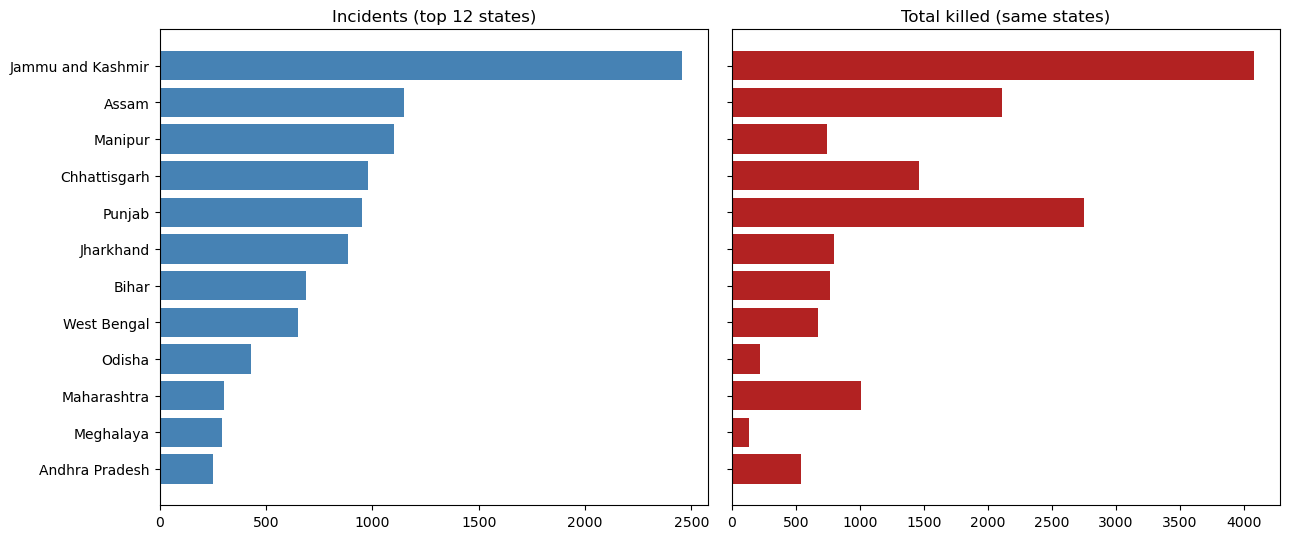

In [35]:
top_states = ind["provstate"].value_counts().head(12).index
state_tbl = (ind[ind["provstate"].isin(top_states)]
             .groupby("provstate").agg(incidents=("eventid", "count"),
                                       killed=("nkill", "sum"))
             .sort_values("incidents"))
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
ax[0].barh(state_tbl.index, state_tbl["incidents"], color="steelblue")
ax[0].set_title("Incidents (top 12 states)")
ax[1].barh(state_tbl.index, state_tbl["killed"], color="firebrick")
ax[1].set_title("Total killed (same states)")
plt.tight_layout()
plt.show()

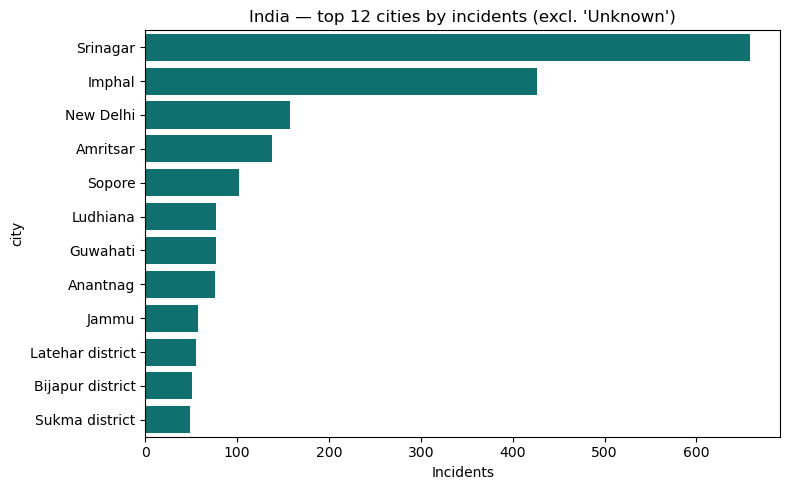

In [36]:
top_cities = ind["city"].value_counts().drop("Unknown", errors="ignore").head(12)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_cities.values, y=top_cities.index, color="teal")
plt.title("India — top 12 cities by incidents (excl. 'Unknown')")
plt.xlabel("Incidents")
plt.tight_layout()
plt.show()

Mapped 11,801 of 11,960 incidents


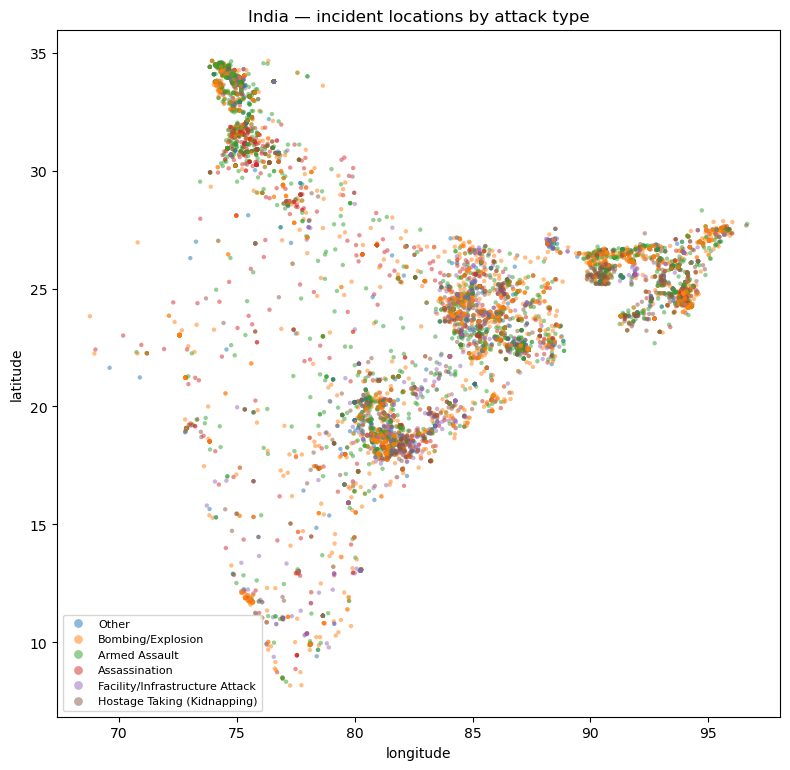

In [37]:
geo = ind.dropna(subset=["latitude", "longitude"])
geo = geo[geo["latitude"].between(6, 37) & geo["longitude"].between(68, 98)]
print(f"Mapped {len(geo):,} of {len(ind):,} incidents")
 
top_types = geo["attacktype1_txt"].value_counts().head(5).index
geo["type_plot"] = np.where(geo["attacktype1_txt"].isin(top_types),
                            geo["attacktype1_txt"], "Other")
plt.figure(figsize=(8, 9))
sns.scatterplot(data=geo, x="longitude", y="latitude", hue="type_plot",
                s=10, alpha=0.5, linewidth=0)
plt.title("India — incident locations by attack type")
plt.legend(title="", loc="lower left", fontsize=8, markerscale=2)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

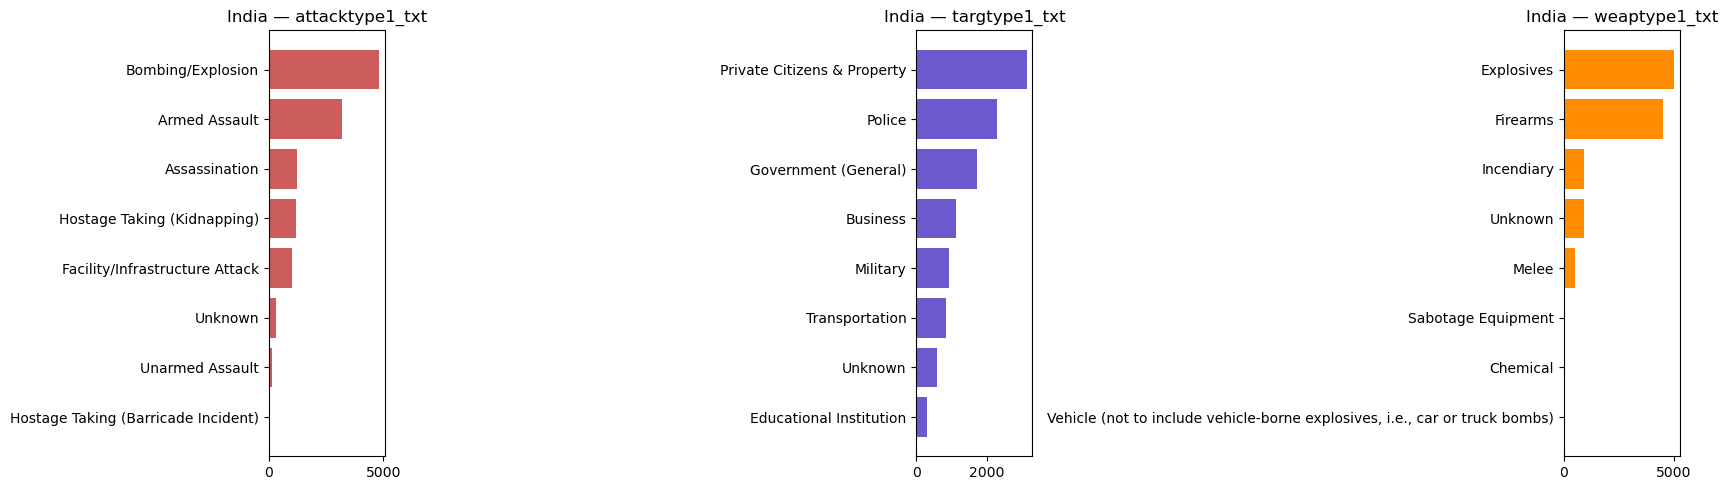

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
for a, col, colr in zip(ax, ["attacktype1_txt", "targtype1_txt", "weaptype1_txt"],
                        ["indianred", "slateblue", "darkorange"]):
    vc = ind[col].value_counts().head(8).sort_values()
    a.barh(vc.index, vc.values, color=colr)
    a.set_title(f"India — {col}")
plt.tight_layout()
plt.show()

'Unknown' perpetrator: 4,263 incidents (35.6%) — excluded from the bars


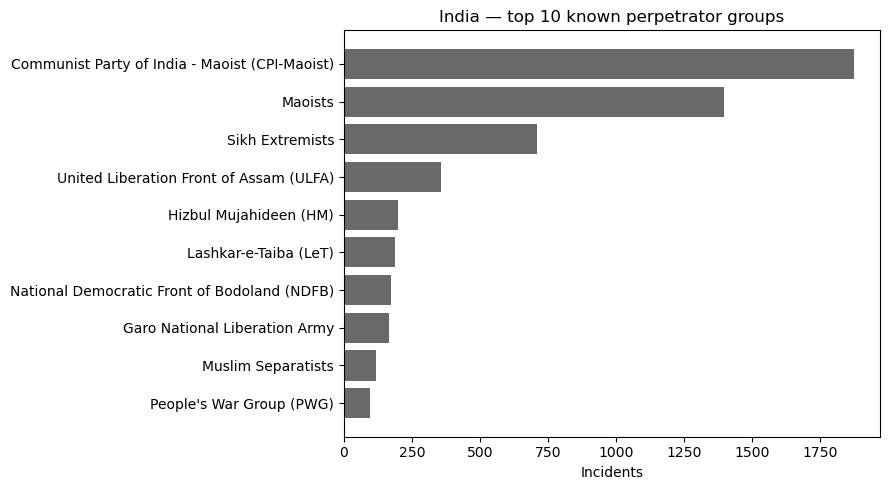

In [39]:
MERGE_MAOISTS = False
g = ind["gname"].copy()
if MERGE_MAOISTS:
    g = g.replace({"Maoists": "Communist Party of India - Maoist (CPI-Maoist)"})
grp = g[g != "Unknown"].value_counts().head(10).sort_values()
print(f"'Unknown' perpetrator: {(g == 'Unknown').sum():,} incidents "
      f"({(g == 'Unknown').mean()*100:.1f}%) — excluded from the bars")
plt.figure(figsize=(9, 5))
plt.barh(grp.index, grp.values, color="dimgray")
plt.title("India — top 10 known perpetrator groups")
plt.xlabel("Incidents")
plt.tight_layout()
plt.show()

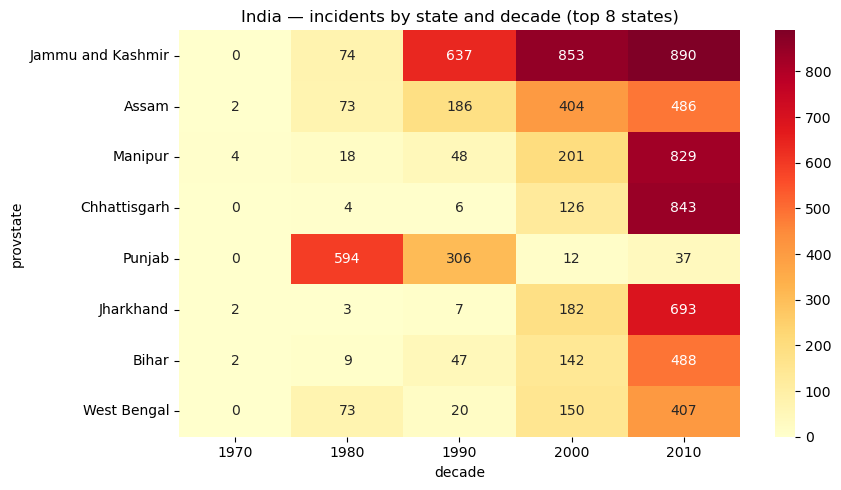

In [40]:
ind["decade"] = (ind["iyear"] // 10) * 10
top8 = ind["provstate"].value_counts().head(8).index
pivot = (ind[ind["provstate"].isin(top8)]
         .pivot_table(index="provstate", columns="decade", values="eventid",
                      aggfunc="count", fill_value=0)
         .loc[top8])
plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd")
plt.title("India — incidents by state and decade (top 8 states)")
plt.tight_layout()
plt.show()
 

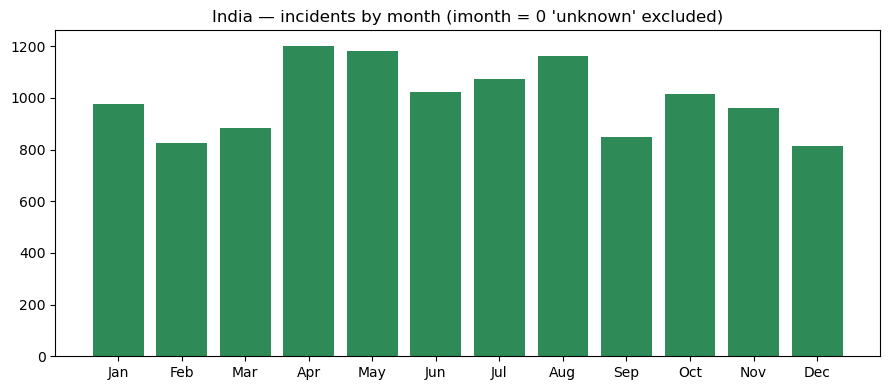

In [41]:
monthly = ind[ind["imonth"] > 0]["imonth"].value_counts().sort_index()
plt.figure(figsize=(9, 4))
plt.bar(monthly.index, monthly.values, color="seagreen")
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.title("India — incidents by month (imonth = 0 'unknown' excluded)")
plt.tight_layout()
plt.show()

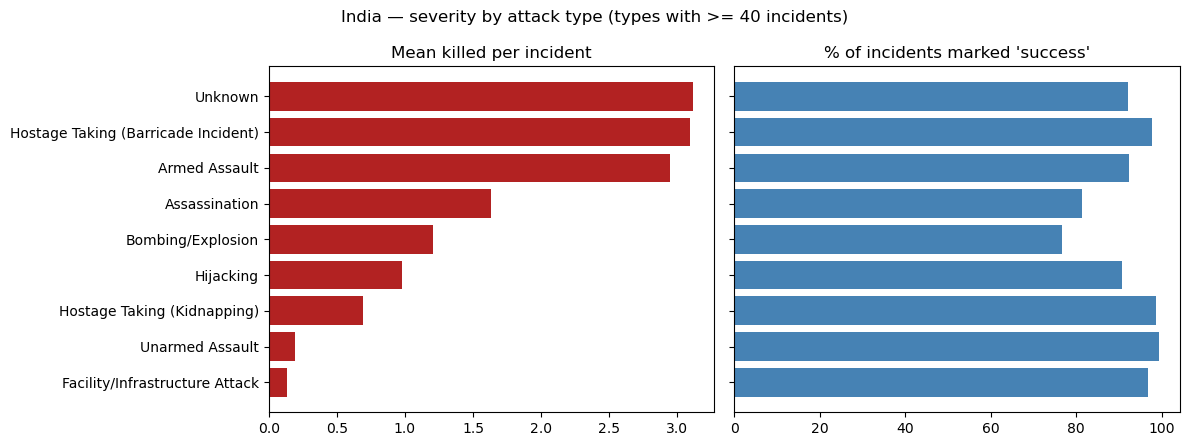

In [42]:
ind["casualties"] = ind["nkill"].fillna(0) + ind["nwound"].fillna(0)
sev = (ind.groupby("attacktype1_txt")
       .agg(incidents=("eventid", "count"),
            mean_killed=("nkill", "mean"),
            success_rate=("success", "mean"))
       .query("incidents >= 40")
       .sort_values("mean_killed"))
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
ax[0].barh(sev.index, sev["mean_killed"], color="firebrick")
ax[0].set_title("Mean killed per incident")
ax[1].barh(sev.index, sev["success_rate"] * 100, color="steelblue")
ax[1].set_title("% of incidents marked 'success'")
plt.suptitle("India — severity by attack type (types with >= 40 incidents)")
plt.tight_layout()
plt.show()

In [43]:
deadliest = (ind.sort_values("nkill", ascending=False)
             .head(10)[["iyear", "provstate", "city", "attacktype1_txt", "gname",
                        "nkill", "nwound"]])
print(deadliest.to_string(index=False))

 iyear    provstate               city                     attacktype1_txt                                          gname  nkill  nwound
  2006  Maharashtra             Mumbai                   Bombing/Explosion                          Lashkar-e-Taiba (LeT)  188.0   817.0
  2010  West Bengal            Jhargam                             Unknown Communist Party of India - Maoist (CPI-Maoist)  115.0   140.0
  1992  Maharashtra             Bombay                       Armed Assault                               Muslim Militants  115.0     0.0
  2010 Chhattisgarh Dantewada district                       Armed Assault Communist Party of India - Maoist (CPI-Maoist)   82.0     0.0
  1994        Assam           Banabari                       Armed Assault                                 Bodo Militants   70.0   100.0
  2008  Maharashtra             Mumbai Hostage Taking (Barricade Incident)                              Deccan Mujahideen   68.0    76.0
  2007      Haryana             Diwana   

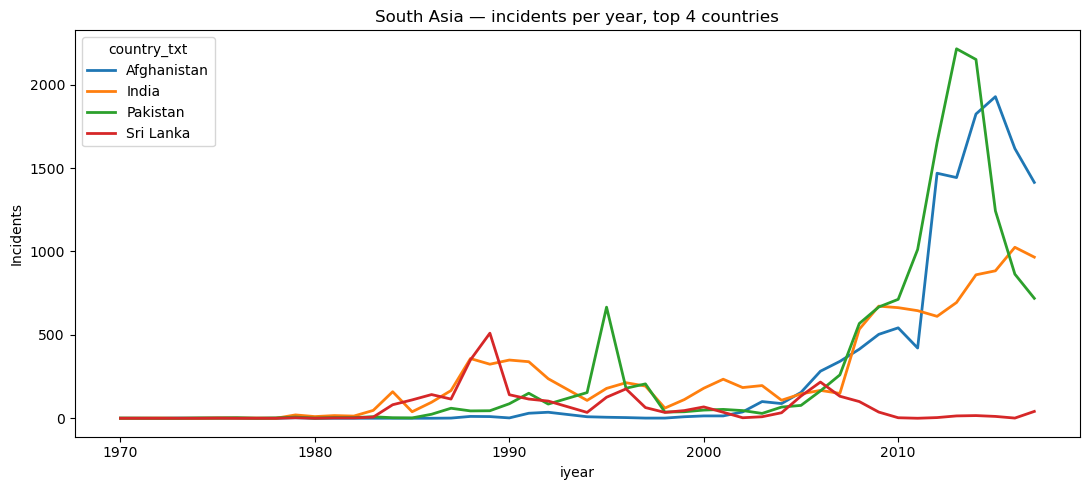

In [44]:
sa = df[df["region_txt"] == "South Asia"]
top_sa = sa["country_txt"].value_counts().head(4).index
sa_year = (sa[sa["country_txt"].isin(top_sa)]
           .groupby(["iyear", "country_txt"]).size().unstack(fill_value=0))
sa_year.plot(figsize=(11, 5), lw=2)
plt.title("South Asia — incidents per year, top 4 countries")
plt.ylabel("Incidents")
plt.tight_layout()
plt.show()

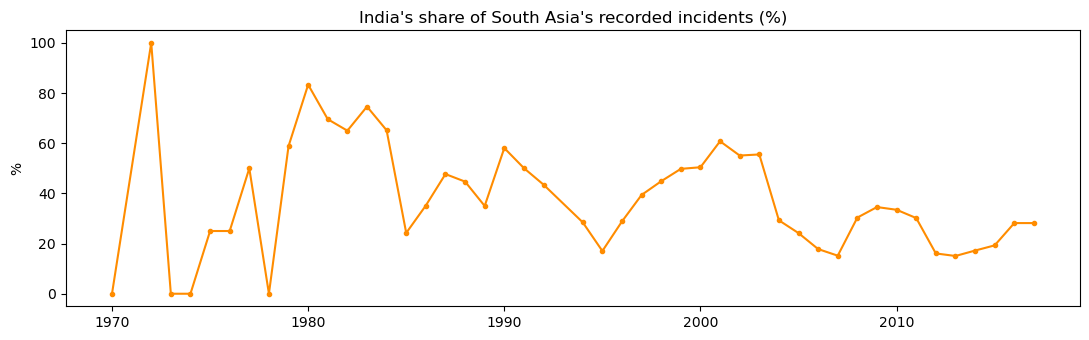

In [45]:
share = (sa.assign(is_india=sa["country_txt"] == "India")
         .groupby("iyear")["is_india"].mean() * 100)
plt.figure(figsize=(11, 3.5))
plt.plot(share.index, share.values, color="darkorange", marker="o", ms=3)
plt.title("India's share of South Asia's recorded incidents (%)")
plt.ylabel("%")
plt.tight_layout()
plt.show()